In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                       "ultralytics", "SoccerNet", "opencv-python-headless",
                       "matplotlib", "Pillow"])


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


0

In [2]:
import numpy as np
import cv2

class SoccerPitch:
    """FIFA soccer pitch 3D model with all keypoints and line definitions.
    
    Coordinate system (meters from pitch center):
        X: pitch length axis  (- = left goal, + = right goal)
        Y: pitch width axis   (- = top touchline, + = bottom touchline)
        Z: height             (0 = ground)
    """
    PITCH_LENGTH = 105.0
    PITCH_WIDTH = 68.0
    PENALTY_AREA_LENGTH = 16.5
    PENALTY_AREA_WIDTH = 40.32
    GOAL_AREA_LENGTH = 5.5
    GOAL_AREA_WIDTH = 18.32
    CENTER_CIRCLE_RADIUS = 9.15
    GOAL_HEIGHT = 2.44
    GOAL_LENGTH = 7.32
    GOAL_LINE_TO_PENALTY_MARK = 11.0

    def __init__(self, pitch_length=105., pitch_width=68.):
        L = pitch_length / 2
        W = pitch_width / 2
        PA_L = self.PENALTY_AREA_LENGTH
        PA_HW = self.PENALTY_AREA_WIDTH / 2
        GA_L = self.GOAL_AREA_LENGTH
        GA_HW = self.GOAL_AREA_WIDTH / 2
        R = self.CENTER_CIRCLE_RADIUS
        GH = self.GOAL_HEIGHT
        GL_H = self.GOAL_LENGTH / 2
        PM = self.GOAL_LINE_TO_PENALTY_MARK

        dx = PA_L - PM
        arc_dy = np.sqrt(R**2 - dx**2)

        self.point_dict = {
            "TL_PITCH_CORNER": np.array([-L, -W, 0.]),
            "TR_PITCH_CORNER": np.array([ L, -W, 0.]),
            "BL_PITCH_CORNER": np.array([-L,  W, 0.]),
            "BR_PITCH_CORNER": np.array([ L,  W, 0.]),
            "T_TOUCH_AND_HALFWAY_LINES_INTERSECTION": np.array([0., -W, 0.]),
            "B_TOUCH_AND_HALFWAY_LINES_INTERSECTION": np.array([0.,  W, 0.]),
            "CENTER_MARK": np.array([0., 0., 0.]),
            "T_HALFWAY_LINE_AND_CENTER_CIRCLE_INTERSECTION": np.array([0., -R, 0.]),
            "B_HALFWAY_LINE_AND_CENTER_CIRCLE_INTERSECTION": np.array([0.,  R, 0.]),
            "L_PENALTY_MARK": np.array([-L + PM, 0., 0.]),
            "R_PENALTY_MARK": np.array([ L - PM, 0., 0.]),
            "L_PENALTY_AREA_TL_CORNER": np.array([-L,        -PA_HW, 0.]),
            "L_PENALTY_AREA_TR_CORNER": np.array([-L + PA_L, -PA_HW, 0.]),
            "L_PENALTY_AREA_BL_CORNER": np.array([-L,         PA_HW, 0.]),
            "L_PENALTY_AREA_BR_CORNER": np.array([-L + PA_L,  PA_HW, 0.]),
            "R_PENALTY_AREA_TL_CORNER": np.array([ L - PA_L, -PA_HW, 0.]),
            "R_PENALTY_AREA_TR_CORNER": np.array([ L,        -PA_HW, 0.]),
            "R_PENALTY_AREA_BL_CORNER": np.array([ L - PA_L,  PA_HW, 0.]),
            "R_PENALTY_AREA_BR_CORNER": np.array([ L,         PA_HW, 0.]),
            "L_GOAL_AREA_TL_CORNER": np.array([-L,        -GA_HW, 0.]),
            "L_GOAL_AREA_TR_CORNER": np.array([-L + GA_L, -GA_HW, 0.]),
            "L_GOAL_AREA_BL_CORNER": np.array([-L,         GA_HW, 0.]),
            "L_GOAL_AREA_BR_CORNER": np.array([-L + GA_L,  GA_HW, 0.]),
            "R_GOAL_AREA_TL_CORNER": np.array([ L - GA_L, -GA_HW, 0.]),
            "R_GOAL_AREA_TR_CORNER": np.array([ L,        -GA_HW, 0.]),
            "R_GOAL_AREA_BL_CORNER": np.array([ L - GA_L,  GA_HW, 0.]),
            "R_GOAL_AREA_BR_CORNER": np.array([ L,         GA_HW, 0.]),
            "L_GOAL_BL_POST": np.array([-L,  GL_H,  0.]),
            "L_GOAL_TL_POST": np.array([-L,  GL_H, -GH]),
            "L_GOAL_BR_POST": np.array([-L, -GL_H,  0.]),
            "L_GOAL_TR_POST": np.array([-L, -GL_H, -GH]),
            "R_GOAL_BL_POST": np.array([ L, -GL_H,  0.]),
            "R_GOAL_TL_POST": np.array([ L, -GL_H, -GH]),
            "R_GOAL_BR_POST": np.array([ L,  GL_H,  0.]),
            "R_GOAL_TR_POST": np.array([ L,  GL_H, -GH]),
            "TL_16M_LINE_AND_PENALTY_ARC_INTERSECTION": np.array([-L + PA_L, -arc_dy, 0.]),
            "BL_16M_LINE_AND_PENALTY_ARC_INTERSECTION": np.array([-L + PA_L,  arc_dy, 0.]),
            "TR_16M_LINE_AND_PENALTY_ARC_INTERSECTION": np.array([ L - PA_L, -arc_dy, 0.]),
            "BR_16M_LINE_AND_PENALTY_ARC_INTERSECTION": np.array([ L - PA_L,  arc_dy, 0.]),
            # Center circle points every 30° (0°=right, CCW; 90°/270° already exist)
            "CC_0":   np.array([ R,                     0.,                    0.]),
            "CC_30":  np.array([ R * np.cos(np.radians(30)),  R * np.sin(np.radians(30)),  0.]),
            "CC_60":  np.array([ R * np.cos(np.radians(60)),  R * np.sin(np.radians(60)),  0.]),
            "CC_120": np.array([ R * np.cos(np.radians(120)), R * np.sin(np.radians(120)), 0.]),
            "CC_150": np.array([ R * np.cos(np.radians(150)), R * np.sin(np.radians(150)), 0.]),
            "CC_180": np.array([-R,                     0.,                    0.]),
            "CC_210": np.array([ R * np.cos(np.radians(210)), R * np.sin(np.radians(210)), 0.]),
            "CC_240": np.array([ R * np.cos(np.radians(240)), R * np.sin(np.radians(240)), 0.]),
            "CC_300": np.array([ R * np.cos(np.radians(300)), R * np.sin(np.radians(300)), 0.]),
            "CC_330": np.array([ R * np.cos(np.radians(330)), R * np.sin(np.radians(330)), 0.]),
        }

        p = self.point_dict
        self.line_extremities = {
            "Side line top":           (p["TL_PITCH_CORNER"], p["TR_PITCH_CORNER"]),
            "Side line bottom":        (p["BL_PITCH_CORNER"], p["BR_PITCH_CORNER"]),
            "Side line left":          (p["TL_PITCH_CORNER"], p["BL_PITCH_CORNER"]),
            "Side line right":         (p["TR_PITCH_CORNER"], p["BR_PITCH_CORNER"]),
            "Middle line":             (p["T_TOUCH_AND_HALFWAY_LINES_INTERSECTION"],
                                        p["B_TOUCH_AND_HALFWAY_LINES_INTERSECTION"]),
            "Big rect. left top":      (p["L_PENALTY_AREA_TL_CORNER"], p["L_PENALTY_AREA_TR_CORNER"]),
            "Big rect. left bottom":   (p["L_PENALTY_AREA_BL_CORNER"], p["L_PENALTY_AREA_BR_CORNER"]),
            "Big rect. left main":     (p["L_PENALTY_AREA_TR_CORNER"], p["L_PENALTY_AREA_BR_CORNER"]),
            "Big rect. right top":     (p["R_PENALTY_AREA_TL_CORNER"], p["R_PENALTY_AREA_TR_CORNER"]),
            "Big rect. right bottom":  (p["R_PENALTY_AREA_BL_CORNER"], p["R_PENALTY_AREA_BR_CORNER"]),
            "Big rect. right main":    (p["R_PENALTY_AREA_TL_CORNER"], p["R_PENALTY_AREA_BL_CORNER"]),
            "Small rect. left top":    (p["L_GOAL_AREA_TL_CORNER"], p["L_GOAL_AREA_TR_CORNER"]),
            "Small rect. left bottom": (p["L_GOAL_AREA_BL_CORNER"], p["L_GOAL_AREA_BR_CORNER"]),
            "Small rect. left main":   (p["L_GOAL_AREA_TR_CORNER"], p["L_GOAL_AREA_BR_CORNER"]),
            "Small rect. right top":   (p["R_GOAL_AREA_TL_CORNER"], p["R_GOAL_AREA_TR_CORNER"]),
            "Small rect. right bottom":(p["R_GOAL_AREA_BL_CORNER"], p["R_GOAL_AREA_BR_CORNER"]),
            "Small rect. right main":  (p["R_GOAL_AREA_TL_CORNER"], p["R_GOAL_AREA_BL_CORNER"]),
            "Goal left crossbar":      (p["L_GOAL_TR_POST"], p["L_GOAL_TL_POST"]),
            "Goal left post left ":    (p["L_GOAL_TL_POST"], p["L_GOAL_BL_POST"]),
            "Goal left post right":    (p["L_GOAL_TR_POST"], p["L_GOAL_BR_POST"]),
            "Goal right crossbar":     (p["R_GOAL_TL_POST"], p["R_GOAL_TR_POST"]),
            "Goal right post left":    (p["R_GOAL_TL_POST"], p["R_GOAL_BL_POST"]),
            "Goal right post right":   (p["R_GOAL_TR_POST"], p["R_GOAL_BR_POST"]),
            "Circle central":          (p["T_HALFWAY_LINE_AND_CENTER_CIRCLE_INTERSECTION"],
                                        p["B_HALFWAY_LINE_AND_CENTER_CIRCLE_INTERSECTION"]),
            "Circle left":             (p["TL_16M_LINE_AND_PENALTY_ARC_INTERSECTION"],
                                        p["BL_16M_LINE_AND_PENALTY_ARC_INTERSECTION"]),
            "Circle right":            (p["TR_16M_LINE_AND_PENALTY_ARC_INTERSECTION"],
                                        p["BR_16M_LINE_AND_PENALTY_ARC_INTERSECTION"]),
        }

    def sample_field_points(self, dist=0.5, dist_circles=0.3):
        polylines = {}
        R = self.CENTER_CIRCLE_RADIUS
        p = self.point_dict

        center = p["CENTER_MARK"]
        n = max(int(2 * np.pi * R / dist_circles), 36)
        angles = np.linspace(0, 2 * np.pi, n, endpoint=True)
        polylines["Circle central"] = [
            np.array([center[0] + R * np.cos(a), center[1] + R * np.sin(a), 0.])
            for a in angles
        ]

        for side in ["left", "right"]:
            prefix = "L" if side == "left" else "R"
            mark = p[f"{prefix}_PENALTY_MARK"]
            top = p[f"T{prefix}_16M_LINE_AND_PENALTY_ARC_INTERSECTION"]
            bot = p[f"B{prefix}_16M_LINE_AND_PENALTY_ARC_INTERSECTION"]

            a_top = np.arctan2(top[1] - mark[1], top[0] - mark[0])
            a_bot = np.arctan2(bot[1] - mark[1], bot[0] - mark[0])
            if side == "left":
                fromA, toA = a_top, a_bot
            else:
                fromA, toA = a_bot, a_top
            if toA < fromA:
                toA += 2 * np.pi
            n_arc = max(int(R * (toA - fromA) / dist_circles), 10)
            arc_angles = np.linspace(fromA, toA, n_arc)
            polylines[f"Circle {side}"] = [
                np.array([mark[0] + R * np.cos(a), mark[1] + R * np.sin(a), 0.])
                for a in arc_angles
            ]

        for key, (start, end) in self.line_extremities.items():
            if "Circle" in key:
                continue
            total = np.linalg.norm(end - start)
            n_seg = max(int(total / dist), 2)
            polylines[key] = [
                start + t * (end - start) for t in np.linspace(0, 1, n_seg)
            ]
        return polylines

    def get_ground_keypoints(self):
        return {k: v for k, v in self.point_dict.items() if v[2] == 0.}


def pan_tilt_roll_to_orientation(pan, tilt, roll):
    Rpan = np.array([[np.cos(pan), -np.sin(pan), 0],
                     [np.sin(pan),  np.cos(pan), 0],
                     [0, 0, 1]])
    Rtilt = np.array([[1, 0, 0],
                      [0, np.cos(tilt), -np.sin(tilt)],
                      [0, np.sin(tilt),  np.cos(tilt)]])
    Rroll = np.array([[np.cos(roll), -np.sin(roll), 0],
                      [np.sin(roll),  np.cos(roll), 0],
                      [0, 0, 1]])
    return Rpan @ Rtilt @ Rroll


class Camera:
    def __init__(self, iwidth=960, iheight=540):
        self.image_width = iwidth
        self.image_height = iheight
        self.position = np.zeros(3)
        self.rotation = np.eye(3)
        self.xfocal_length = 1.0
        self.yfocal_length = 1.0
        self.principal_point = (iwidth / 2, iheight / 2)
        self.calibration = np.eye(3)
        self.radial_distortion = np.zeros(6)
        self.tangential_disto = np.zeros(2)
        self.thin_prism_disto = np.zeros(4)

    def from_homography(self, H):
        success, _ = self._estimate_calibration(H)
        if not success:
            return False
        hprim = np.linalg.inv(self.calibration) @ H
        lam1 = 1.0 / np.linalg.norm(hprim[:, 0])
        lam2 = 1.0 / np.linalg.norm(hprim[:, 1])
        lam3 = np.sqrt(lam1 * lam2)
        r0 = hprim[:, 0] * lam1
        r1 = hprim[:, 1] * lam2
        r2 = np.cross(r0, r1)
        R = np.column_stack((r0, r1, r2))
        u, s, vh = np.linalg.svd(R)
        R = u @ vh
        if np.linalg.det(R) < 0:
            u[:, 2] *= -1
            R = u @ vh
        self.rotation = R
        t = hprim[:, 2] * lam3
        self.position = -R.T @ t
        return True

    def _estimate_calibration(self, H):
        h = H.flatten()
        A = np.zeros((5, 6))
        A[0, 1] = 1.0
        A[1, 0] = 1.0
        A[1, 2] = -1.0
        A[2, 3] = self.principal_point[1] / self.principal_point[0]
        A[2, 4] = -1.0
        A[3] = [h[0]*h[1], h[0]*h[4]+h[1]*h[3], h[3]*h[4],
                h[0]*h[7]+h[1]*h[6], h[3]*h[7]+h[4]*h[6], h[6]*h[7]]
        A[4] = [h[0]**2-h[1]**2, 2*(h[0]*h[3]-h[1]*h[4]), h[3]**2-h[4]**2,
                2*(h[0]*h[6]-h[1]*h[7]), 2*(h[3]*h[6]-h[4]*h[7]), h[6]**2-h[7]**2]
        _, _, vh = np.linalg.svd(A)
        w = vh[-1]
        W = np.array([[w[0]/w[5], w[1]/w[5], w[3]/w[5]],
                      [w[1]/w[5], w[2]/w[5], w[4]/w[5]],
                      [w[3]/w[5], w[4]/w[5], 1.0]])
        try:
            Ktinv = np.linalg.cholesky(W)
        except np.linalg.LinAlgError:
            return False, np.eye(3)
        K = np.linalg.inv(Ktinv.T)
        K /= K[2, 2]
        self.xfocal_length = K[0, 0]
        self.yfocal_length = K[1, 1]
        self.principal_point = (self.image_width / 2, self.image_height / 2)
        self.calibration = np.array([
            [self.xfocal_length, 0, self.principal_point[0]],
            [0, self.yfocal_length, self.principal_point[1]],
            [0, 0, 1]
        ])
        return True, K

    def project_point(self, point3D):
        p = point3D - self.position
        rp = self.rotation @ p
        if rp[2] <= 1e-3:
            return np.zeros(3)
        rp = rp / rp[2]
        x = rp[0] * self.xfocal_length + self.principal_point[0]
        y = rp[1] * self.yfocal_length + self.principal_point[1]
        return np.array([x, y, 1.0])


print("SoccerPitch and Camera classes defined.")

SoccerPitch and Camera classes defined.


In [3]:
from SoccerNet.Downloader import SoccerNetDownloader

mySoccerNetDownloader = SoccerNetDownloader(LocalDirectory="./data/SoccerNet/CameraCalibration")
mySoccerNetDownloader.downloadDataTask(
    task="calibration-2023",
    split=["train", "valid", "test"]
)

./data/SoccerNet/CameraCalibration/calibration-2023/train.zip already exists
./data/SoccerNet/CameraCalibration/calibration-2023/valid.zip already exists
./data/SoccerNet/CameraCalibration/calibration-2023/test.zip already exists


Image size: 960x540
Annotated line classes: ['Circle left', 'Small rect. left top', 'Small rect. left main', 'Small rect. left bottom', 'Big rect. left top', 'Big rect. left main', 'Big rect. left bottom', 'Side line top', 'Side line left', 'Goal left post right', 'Goal left crossbar', 'Goal left post left ']
Candidate correspondences: 32
Homography inliers: 9/32


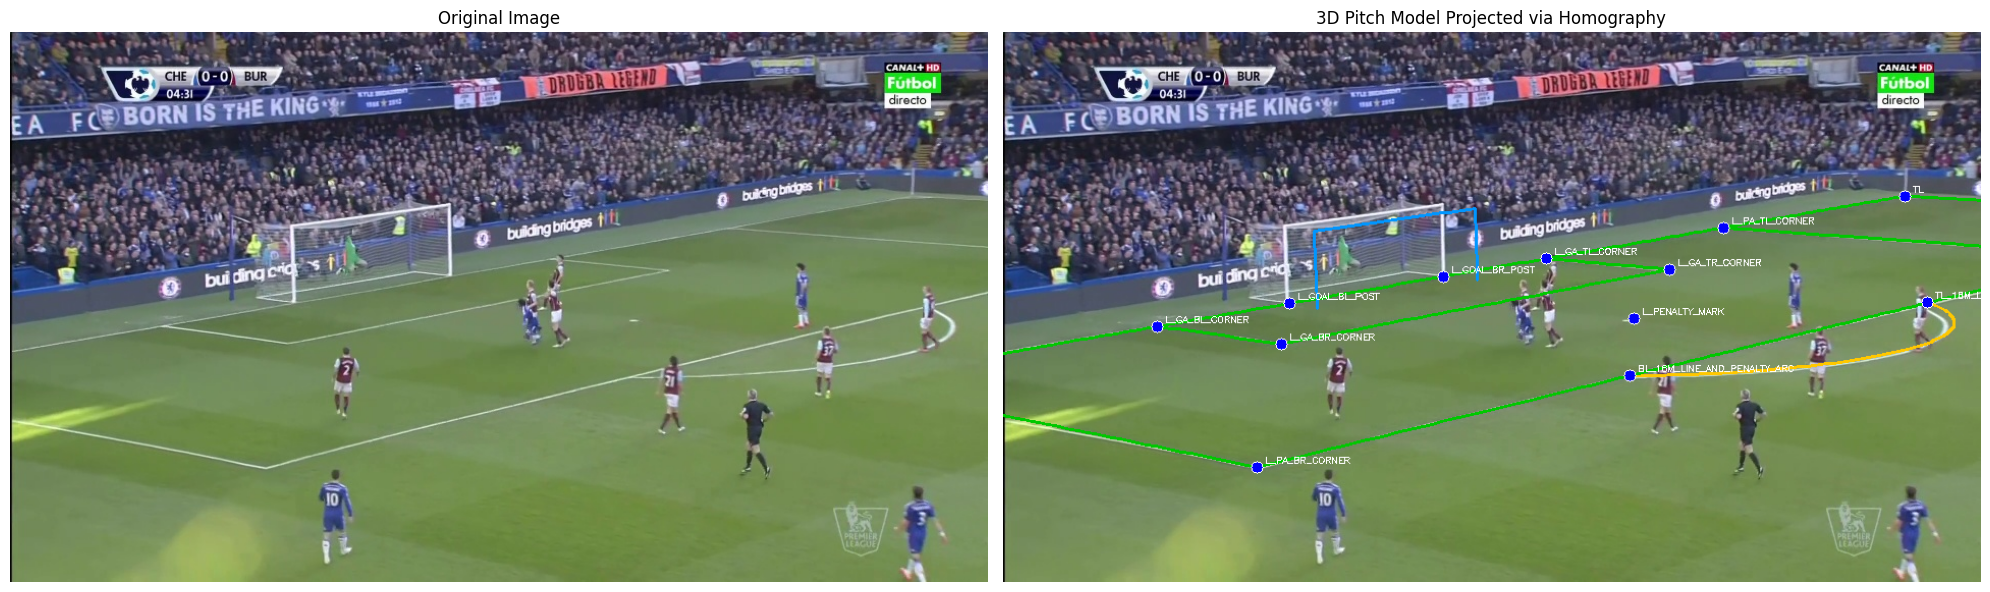

In [4]:
import zipfile, json, io
from PIL import Image
import matplotlib.pyplot as plt

ZIP_PATH = "data/SoccerNet/CameraCalibration/calibration-2023/train.zip"
SAMPLE_IDX = "00000"

with zipfile.ZipFile(ZIP_PATH) as z:
    img_bytes = z.read(f"train/{SAMPLE_IDX}.jpg")
    ann = json.loads(z.read(f"train/{SAMPLE_IDX}.json"))

img = np.array(Image.open(io.BytesIO(img_bytes)))
img_h, img_w = img.shape[:2]
print(f"Image size: {img_w}x{img_h}")
print(f"Annotated line classes: {list(ann.keys())}")

pitch = SoccerPitch()
SKIP_CLASSES = {"Circle central", "Circle left", "Circle right",
                "Goal left crossbar", "Goal left post left ",
                "Goal left post right", "Goal right crossbar",
                "Goal right post left", "Goal right post right",
                "Goal unknown", "Line unknown"}

pts_2d, pts_3d = [], []
for cls_name, (pt3d_a, pt3d_b) in pitch.line_extremities.items():
    if cls_name in SKIP_CLASSES or cls_name not in ann:
        continue
    ann_pts = ann[cls_name]
    if len(ann_pts) < 2:
        continue
    p2d_first = np.array([ann_pts[0]["x"] * img_w, ann_pts[0]["y"] * img_h])
    p2d_last  = np.array([ann_pts[-1]["x"] * img_w, ann_pts[-1]["y"] * img_h])
    pts_2d += [p2d_first, p2d_last, p2d_first, p2d_last]
    pts_3d += [pt3d_a[:2], pt3d_b[:2], pt3d_b[:2], pt3d_a[:2]]

pts_2d = np.array(pts_2d, dtype=np.float32)
pts_3d = np.array(pts_3d, dtype=np.float32)
print(f"Candidate correspondences: {len(pts_2d)}")

H, mask = cv2.findHomography(pts_3d, pts_2d, cv2.RANSAC, 5.0)
n_inliers = int(mask.sum()) if mask is not None else 0
print(f"Homography inliers: {n_inliers}/{len(mask)}")

cam = Camera(iwidth=img_w, iheight=img_h)
cam_ok = cam.from_homography(H)

overlay = img.copy()
polylines = pitch.sample_field_points(dist=0.3, dist_circles=0.2)
line_colors = {"Circle central": (255, 255, 0), "Circle left": (255, 200, 0), "Circle right": (255, 200, 0)}
goal_keys = {"Goal left crossbar", "Goal left post left ",
             "Goal left post right", "Goal right crossbar",
             "Goal right post left", "Goal right post right"}

for cls_name, pts3d in polylines.items():
    is_goal = cls_name in goal_keys
    color = line_colors.get(cls_name, (0, 200, 0) if not is_goal else (0, 150, 255))
    prev = None
    for pt in pts3d:
        if is_goal and cam_ok:
            proj = cam.project_point(pt)
        else:
            p = H @ np.array([pt[0], pt[1], 1.0])
            proj = p / p[2] if abs(p[2]) > 1e-6 else np.zeros(3)
        if proj[2] == 0:
            prev = None; continue
        px, py = int(proj[0]), int(proj[1])
        if prev is not None:
            ppx, ppy = prev
            if (0 <= px < img_w and 0 <= py < img_h) or (0 <= ppx < img_w and 0 <= ppy < img_h):
                cv2.line(overlay, (ppx, ppy), (px, py), color, 2)
        prev = (px, py)

ground_kps = pitch.get_ground_keypoints()
for name, pt3d in ground_kps.items():
    p = H @ np.array([pt3d[0], pt3d[1], 1.0])
    if abs(p[2]) < 1e-6:
        continue
    p = p / p[2]
    px, py = int(p[0]), int(p[1])
    if 0 <= px < img_w and 0 <= py < img_h:
        cv2.circle(overlay, (px, py), 6, (0, 0, 255), -1)
        cv2.circle(overlay, (px, py), 6, (255, 255, 255), 1)
        short = name.replace("_PITCH_CORNER", "").replace("_PENALTY_AREA_", "_PA_") \
                     .replace("_GOAL_AREA_", "_GA_").replace("_INTERSECTION", "")
        cv2.putText(overlay, short, (px + 8, py - 4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.30, (255, 255, 255), 1)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
axes[0].imshow(img);  axes[0].set_title("Original Image");  axes[0].axis("off")
axes[1].imshow(overlay);  axes[1].set_title("3D Pitch Model Projected via Homography");  axes[1].axis("off")
plt.tight_layout();  plt.show()

In [5]:

import urllib.request, tarfile
from pathlib import Path

WC_DIR = Path("data/worldcup/raw")
WC_URL = "https://nhoma.github.io/data/soccer_data.tar.gz"
WC_TAR = Path("data/worldcup/soccer_data.tar.gz")

if not (WC_DIR / "train_val").exists():
    WC_TAR.parent.mkdir(parents=True, exist_ok=True)
    print("Downloading WorldCup 2014 dataset...")
    urllib.request.urlretrieve(WC_URL, WC_TAR)
    WC_DIR.mkdir(parents=True, exist_ok=True)
    print("Extracting...")
    with tarfile.open(WC_TAR, "r:gz") as tar:
        tar.extractall(WC_DIR)
    # The tar extracts with a top-level folder; flatten if needed
    extracted = [p for p in WC_DIR.iterdir() if p.name != WC_TAR.name]
    if len(extracted) == 1 and extracted[0].is_dir() and extracted[0].name != "train_val":
        for child in extracted[0].iterdir():
            child.rename(WC_DIR / child.name)
        extracted[0].rmdir()
    WC_TAR.unlink()
    print(f"Extracted to {WC_DIR}")
else:
    print(f"WorldCup 2014 already downloaded at {WC_DIR}")

n_train = len(list((WC_DIR / "train_val").glob("*.jpg")))
n_test = len(list((WC_DIR / "test").glob("*.jpg")))
print(f"  train_val: {n_train} images")
print(f"  test:      {n_test} images")


WorldCup 2014 already downloaded at data/worldcup/raw
  train_val: 209 images
  test:      186 images


In [6]:

import urllib.request, zipfile
from pathlib import Path

TSWC_DIR = Path("data/ts_worldcup")
TSWC_URL = "https://cgv.cs.nthu.edu.tw/KpSFR_data/TS-WorldCup.zip"
TSWC_ZIP = Path("data/ts_worldcup.zip")

if not (TSWC_DIR / "TS-WorldCup" / "train.txt").exists():
    TSWC_DIR.mkdir(parents=True, exist_ok=True)
    if not TSWC_ZIP.exists():
        print("Downloading TS-WorldCup dataset (~600 MB)...")
        urllib.request.urlretrieve(TSWC_URL, TSWC_ZIP)
    print("Extracting...")
    with zipfile.ZipFile(TSWC_ZIP) as zf:
        zf.extractall(TSWC_DIR)
    TSWC_ZIP.unlink()
    print(f"Extracted to {TSWC_DIR}")
else:
    print(f"TS-WorldCup already downloaded at {TSWC_DIR}")

tswc_root = TSWC_DIR / "TS-WorldCup"
train_clips = (tswc_root / "train.txt").read_text().strip().split("\n")
test_clips = (tswc_root / "test.txt").read_text().strip().split("\n")
n_imgs = len(list(tswc_root.rglob("*.jpg")))
print(f"  Total images: {n_imgs}")
print(f"  Train clips:  {len(train_clips)}")
print(f"  Test clips:   {len(test_clips)}")


TS-WorldCup already downloaded at data/ts_worldcup
  Total images: 3812
  Train clips:  33
  Test clips:   10


In [ ]:
"""
Build YOLO-pose dataset from all sources with random 80/10/10 split:
  1. SoccerNet calibration-2023  (line extremity annotations)
  2. WorldCup 2014               (homography matrices, text format)
  3. TS-WorldCup                  (homography matrices, .npy format)

All images are pooled together and randomly split into train/val/test
to ensure uniform distribution across sources.
"""
import os, zipfile, json, io, shutil, random
from pathlib import Path
from PIL import Image
import numpy as np
import cv2
import matplotlib.pyplot as plt

# ═══════════════════════════════════════════════════════════════════════
# Keypoint definitions — 31 ground-plane points (Z == 0)
# ═══════════════════════════════════════════════════════════════════════
KEYPOINT_NAMES = [
    "TL_PITCH_CORNER",                                  # 0
    "TR_PITCH_CORNER",                                  # 1
    "BL_PITCH_CORNER",                                  # 2
    "BR_PITCH_CORNER",                                  # 3
    "T_TOUCH_AND_HALFWAY_LINES_INTERSECTION",           # 4
    "B_TOUCH_AND_HALFWAY_LINES_INTERSECTION",           # 5
    "CENTER_MARK",                                      # 6
    "T_HALFWAY_LINE_AND_CENTER_CIRCLE_INTERSECTION",    # 7
    "B_HALFWAY_LINE_AND_CENTER_CIRCLE_INTERSECTION",    # 8
    "L_PENALTY_MARK",                                   # 9
    "R_PENALTY_MARK",                                   # 10
    "L_PENALTY_AREA_TL_CORNER",                         # 11
    "L_PENALTY_AREA_TR_CORNER",                         # 12
    "L_PENALTY_AREA_BL_CORNER",                         # 13
    "L_PENALTY_AREA_BR_CORNER",                         # 14
    "R_PENALTY_AREA_TL_CORNER",                         # 15
    "R_PENALTY_AREA_TR_CORNER",                         # 16
    "R_PENALTY_AREA_BL_CORNER",                         # 17
    "R_PENALTY_AREA_BR_CORNER",                         # 18
    "L_GOAL_AREA_TL_CORNER",                            # 19
    "L_GOAL_AREA_TR_CORNER",                            # 20
    "L_GOAL_AREA_BL_CORNER",                            # 21
    "L_GOAL_AREA_BR_CORNER",                            # 22
    "R_GOAL_AREA_TL_CORNER",                            # 23
    "R_GOAL_AREA_TR_CORNER",                            # 24
    "R_GOAL_AREA_BL_CORNER",                            # 25
    "R_GOAL_AREA_BR_CORNER",                            # 26
    "TL_16M_LINE_AND_PENALTY_ARC_INTERSECTION",         # 27
    "BL_16M_LINE_AND_PENALTY_ARC_INTERSECTION",         # 28
    "TR_16M_LINE_AND_PENALTY_ARC_INTERSECTION",         # 29
    "BR_16M_LINE_AND_PENALTY_ARC_INTERSECTION",         # 30
    # Center circle points every 30° (0°=right along +X, CCW)
    # 90° and 270° already exist as indices 8 and 7
    "CC_0",                                             # 31
    "CC_30",                                            # 32
    "CC_60",                                            # 33
    "CC_120",                                           # 34
    "CC_150",                                           # 35
    "CC_180",                                           # 36
    "CC_210",                                           # 37
    "CC_240",                                           # 38
    "CC_300",                                           # 39
    "CC_330",                                           # 40
]
N_KP = len(KEYPOINT_NAMES)

pitch = SoccerPitch()
WORLD_XY = np.array([pitch.point_dict[n][:2] for n in KEYPOINT_NAMES], dtype=np.float32)

# Horizontal-flip symmetry indices (left <-> right, i.e. negate X)
# Center circle: CC_0↔CC_180, CC_30↔CC_150, CC_60↔CC_120, CC_210↔CC_330, CC_240↔CC_300
FLIP_IDX = [
    1, 0, 3, 2,
    4, 5, 6, 7, 8,
    10, 9,
    16, 15, 18, 17, 12, 11, 14, 13,
    24, 23, 26, 25, 20, 19, 22, 21,
    29, 30, 27, 28,
    36, 35, 34, 33, 32, 31, 40, 39, 38, 37,
]

SKIP_CLASSES = {
    "Circle central", "Circle left", "Circle right",
    "Goal left crossbar", "Goal left post left ",
    "Goal left post right", "Goal right crossbar",
    "Goal right post left", "Goal right post right",
    "Goal unknown", "Line unknown",
}

# World meters -> template pixels (115x74 px = 105x68 m pitch)
W_TO_TPL = np.array([
    [115.0/105.0, 0,           52.5*115.0/105.0],
    [0,           74.0/68.0,   34.0*74.0/68.0  ],
    [0,           0,           1               ],
], dtype=np.float64)

# ═══════════════════════════════════════════════════════════════════════
# Dataset paths
# ═══════════════════════════════════════════════════════════════════════
DATASET_ROOT = Path("datasets/pitch_keypoints_extended")
SN_DIR = Path("data/SoccerNet/CameraCalibration/calibration-2023")
WC_DIR = Path("data/worldcup/raw")
TSWC_DIR = Path("data/ts_worldcup/TS-WorldCup")

if DATASET_ROOT.exists():
    shutil.rmtree(DATASET_ROOT)
for s in ("train", "val", "test"):
    (DATASET_ROOT / "images" / s).mkdir(parents=True)
    (DATASET_ROOT / "labels" / s).mkdir(parents=True)

# ═══════════════════════════════════════════════════════════════════════
# Core functions
# ═══════════════════════════════════════════════════════════════════════
def _homography(ann, w, h):
    pts2, pts3 = [], []
    for cn, (a, b) in pitch.line_extremities.items():
        if cn in SKIP_CLASSES or cn not in ann:
            continue
        ap = ann[cn]
        if len(ap) < 2:
            continue
        f = np.array([ap[0]["x"] * w, ap[0]["y"] * h])
        l = np.array([ap[-1]["x"] * w, ap[-1]["y"] * h])
        pts2 += [f, l, f, l]
        pts3 += [a[:2], b[:2], b[:2], a[:2]]
    if len(pts2) < 8:
        return None, 0
    H, mask = cv2.findHomography(np.float32(pts3), np.float32(pts2), cv2.RANSAC, 5.0)
    return H, int(mask.sum()) if mask is not None else 0


def _project(H, w, h):
    kps = np.zeros((N_KP, 3), dtype=np.float32)
    for i, (wx, wy) in enumerate(WORLD_XY):
        p = H @ [wx, wy, 1.0]
        if abs(p[2]) < 1e-6:
            continue
        nx, ny = p[0] / (p[2] * w), p[1] / (p[2] * h)
        if -0.05 < nx < 1.05 and -0.05 < ny < 1.05:
            kps[i] = [np.clip(nx, 0, 1), np.clip(ny, 0, 1), 2]
    return kps


def _label(kps):
    vis = kps[:, 2] > 0
    if vis.sum() < 4:
        return None
    vx, vy = kps[vis, 0], kps[vis, 1]
    pad = 0.02
    x1 = max(0, vx.min() - pad); x2 = min(1, vx.max() + pad)
    y1 = max(0, vy.min() - pad); y2 = min(1, vy.max() + pad)
    parts = [f"0 {(x1+x2)/2:.6f} {(y1+y2)/2:.6f} {x2-x1:.6f} {y2-y1:.6f}"]
    for i in range(N_KP):
        if kps[i, 2] > 0:
            parts.append(f"{kps[i,0]:.6f} {kps[i,1]:.6f} 2")
        else:
            parts.append("0 0 0")
    return " ".join(parts)


# ═══════════════════════════════════════════════════════════════════════
# Collect all valid samples into a single pool
# Each entry: (output_name, label_text, source_type, source_info)
#   source_type='zip':  source_info = (zip_path_str, entry_name)
#   source_type='file': source_info = img_path_str
# ═══════════════════════════════════════════════════════════════════════
entries = []

# --- Part 1: SoccerNet calibration-2023 (all splits) ---
for sn_split, zname in [("train", "train.zip"), ("valid", "valid.zip"), ("test", "test.zip")]:
    zp = SN_DIR / zname
    if not zp.exists():
        print(f"  SoccerNet {sn_split}: zip not found, skipping")
        continue
    ok = skip = 0
    with zipfile.ZipFile(zp) as z:
        jpgs = sorted(n for n in z.namelist() if n.endswith(".jpg"))
        print(f"  SoccerNet {sn_split}: {len(jpgs)} images ...")
        for idx, jname in enumerate(jpgs):
            stem = Path(jname).stem
            jdata = z.read(jname)
            pil = Image.open(io.BytesIO(jdata))
            w, h = pil.size
            pil.close()
            try:
                ann = json.loads(z.read(jname.replace(".jpg", ".json")))
            except (KeyError, json.JSONDecodeError):
                skip += 1; continue
            H, ni = _homography(ann, w, h)
            if H is None or ni < 6:
                skip += 1; continue
            kps = _project(H, w, h)
            lbl = _label(kps)
            if lbl is None:
                skip += 1; continue
            entries.append((f"sn_{sn_split}_{stem}", lbl, "zip", (str(zp), jname)))
            ok += 1
            if (idx + 1) % 3000 == 0:
                print(f"    {idx+1}/{len(jpgs)} ... {ok} valid")
    print(f"    -> {ok} valid, {skip} skipped")

# --- Part 2: WorldCup 2014 (all folders) ---
for wc_folder in ["train_val", "test"]:
    src = WC_DIR / wc_folder
    if not src.exists():
        print(f"  WorldCup {wc_folder}: not found, skipping")
        continue
    ok = skip = 0
    h_files = sorted(src.glob("*.homographyMatrix"))
    print(f"  WorldCup {wc_folder}: {len(h_files)} images ...")
    for hf in h_files:
        stem = hf.stem
        img_path = src / f"{stem}.jpg"
        if not img_path.exists():
            skip += 1; continue
        pil = Image.open(img_path)
        w, h = pil.size
        pil.close()
        H_raw = np.loadtxt(hf)
        try:
            H_world_to_frame = np.linalg.inv(H_raw) @ W_TO_TPL
        except np.linalg.LinAlgError:
            skip += 1; continue
        kps = _project(H_world_to_frame, w, h)
        lbl = _label(kps)
        if lbl is None:
            skip += 1; continue
        entries.append((f"wc_{stem}", lbl, "file", str(img_path)))
        ok += 1
    print(f"    -> {ok} valid, {skip} skipped")

# --- Part 3: TS-WorldCup (all clips) ---
if TSWC_DIR.exists():
    ok = skip = total_npy = 0
    for side in ("left", "right"):
        ann_dir = TSWC_DIR / "Annotations" / "80_95" / side
        if not ann_dir.exists():
            continue
        for clip_dir in sorted(ann_dir.iterdir()):
            if not clip_dir.is_dir():
                continue
            npy_files = sorted(clip_dir.glob("*_homography.npy"))
            total_npy += len(npy_files)
            for npy_path in npy_files:
                stem = npy_path.name.replace("_homography.npy", "")
                img_path = TSWC_DIR / "Dataset" / "80_95" / side / clip_dir.name / f"{stem}.jpg"
                if not img_path.exists():
                    skip += 1; continue
                pil = Image.open(img_path)
                w, h = pil.size
                pil.close()
                H_raw = np.load(npy_path)
                try:
                    H_world_to_frame = np.linalg.inv(H_raw) @ W_TO_TPL
                except np.linalg.LinAlgError:
                    skip += 1; continue
                kps = _project(H_world_to_frame, w, h)
                lbl = _label(kps)
                if lbl is None:
                    skip += 1; continue
                entries.append((f"tswc_{side}_{clip_dir.name}_{stem}", lbl, "file", str(img_path)))
                ok += 1
    print(f"  TS-WorldCup: {ok} valid / {total_npy} total, {skip} skipped")
else:
    print("  TS-WorldCup: not found, skipping")

print(f"\nTotal valid samples: {len(entries)}")

# ═══════════════════════════════════════════════════════════════════════
# Random split: 80% train, 10% val, 10% test
# ═══════════════════════════════════════════════════════════════════════
random.seed(42)
random.shuffle(entries)

n = len(entries)
n_test = n // 10
n_val = n // 10
n_train = n - n_val - n_test

splits = (["train"] * n_train) + (["val"] * n_val) + (["test"] * n_test)

# Count per source per split
from collections import Counter
source_split_counts = Counter()

for (oname, lbl, stype, sinfo), split in zip(entries, splits):
    idir = DATASET_ROOT / "images" / split
    ldir = DATASET_ROOT / "labels" / split

    if stype == "zip":
        zp_str, entry_name = sinfo
        with zipfile.ZipFile(zp_str) as z:
            img_data = z.read(entry_name)
        with open(idir / f"{oname}.jpg", "wb") as f:
            f.write(img_data)
    else:
        shutil.copy2(sinfo, idir / f"{oname}.jpg")

    (ldir / f"{oname}.txt").write_text(lbl)

    src = oname.split("_")[0]  # "sn", "wc", or "tswc"
    source_split_counts[(src, split)] += 1

# ═══════════════════════════════════════════════════════════════════════
# Write data.yaml + keypoint metadata
# ═══════════════════════════════════════════════════════════════════════
kp_meta = {n: WORLD_XY[i].tolist() for i, n in enumerate(KEYPOINT_NAMES)}
(DATASET_ROOT / "keypoint_definitions.json").write_text(json.dumps(kp_meta, indent=2))

yaml_txt = f"""path: {DATASET_ROOT.resolve()}
train: images/train
val: images/val
test: images/test

kpt_shape: [{N_KP}, 3]
flip_idx: {FLIP_IDX}

names:
  0: pitch
"""
(DATASET_ROOT / "data.yaml").write_text(yaml_txt)

n_train = len(list((DATASET_ROOT / "images" / "train").glob("*.jpg")))
n_val   = len(list((DATASET_ROOT / "images" / "val").glob("*.jpg")))
n_test  = len(list((DATASET_ROOT / "images" / "test").glob("*.jpg")))

print(f"\n{'='*60}")
print(f"  Dataset: {DATASET_ROOT.resolve()}")
print(f"    train: {n_train:>6} images")
print(f"    val:   {n_val:>6} images")
print(f"    test:  {n_test:>6} images")
print(f"  Keypoints: {N_KP}")
print(f"\n  Per-source breakdown:")
for src_label, src_prefix in [("SoccerNet", "sn"), ("WorldCup", "wc"), ("TS-WorldCup", "tswc")]:
    tr = source_split_counts.get((src_prefix, "train"), 0)
    va = source_split_counts.get((src_prefix, "val"), 0)
    te = source_split_counts.get((src_prefix, "test"), 0)
    tot = tr + va + te
    if tot > 0:
        print(f"    {src_label:>12}: {tr:>5} train / {va:>4} val / {te:>4} test  (total {tot})")

# ═══════════════════════════════════════════════════════════════════════
# Visual verification: 3 images from each source (from train split)
# ═══════════════════════════════════════════════════════════════════════
sn_imgs = sorted((DATASET_ROOT / "images" / "train").glob("sn_*.jpg"))[:3]
wc_imgs = sorted((DATASET_ROOT / "images" / "train").glob("wc_*.jpg"))[:3]
tswc_imgs = sorted((DATASET_ROOT / "images" / "train").glob("tswc_*.jpg"))[:3]
sample_imgs = sn_imgs + wc_imgs + tswc_imgs

n_samples = len(sample_imgs)
n_cols = 3
n_rows = (n_samples + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
for ax in axes.flat:
    ax.axis("off")

for ax, img_path in zip(axes.flat, sample_imgs):
    img = np.array(Image.open(img_path))
    ih, iw = img.shape[:2]
    split_name = img_path.parent.name
    lbl_path = DATASET_ROOT / "labels" / split_name / (img_path.stem + ".txt")
    parts = lbl_path.read_text().split()
    n_vis = 0
    for k in range(N_KP):
        off = 5 + k * 3
        kx, ky, kv = float(parts[off]), float(parts[off+1]), int(parts[off+2])
        if kv > 0:
            px, py = int(kx * iw), int(ky * ih)
            cv2.circle(img, (px, py), 5, (255, 0, 0), -1)
            cv2.circle(img, (px, py), 5, (255, 255, 255), 1)
            n_vis += 1
    if img_path.stem.startswith("tswc_"):
        src_name = "TS-WorldCup"
    elif img_path.stem.startswith("wc_"):
        src_name = "WorldCup"
    else:
        src_name = "SoccerNet"
    ax.imshow(img)
    ax.set_title(f"[{src_name}] {n_vis} keypoints", fontsize=8)
    ax.axis("off")

plt.suptitle("Dataset verification: red dots = projected keypoints\nRow 1: SoccerNet  |  Row 2: WorldCup 2014  |  Row 3: TS-WorldCup")
plt.tight_layout();  plt.show()

  SoccerNet train: 16463 images ...


KeyboardInterrupt: 

In [7]:

"""
Train YOLOv8l-pose on merged dataset.
Do NOT run this cell here — execute on a high-performance GPU machine.
"""
from ultralytics import YOLO
import torch

device = 0 if torch.cuda.is_available() else "cpu"
print(f"Training device: {'GPU (' + torch.cuda.get_device_name(0) + ')' if device == 0 else 'CPU'}")
if device == "cpu":
    print("Warning: CPU training is very slow. Use a GPU machine.")

model = YOLO("yolov8l-pose.pt")
model.train(
    data="datasets/pitch_keypoints/data.yaml",
    epochs=150,
    imgsz=1280,
    batch=-1,
    patience=30,
    project="runs/pose",
    name="pitch_keypoints_v2",
    exist_ok=True,
    fliplr=0.5,
    mosaic=0.0,
    scale=0.3,
    translate=0.1,
    degrees=3.0,
    perspective=0.0005,
    device=device,
)

metrics = model.val(split="test")
print(f"\n{'='*60}")
print(f"  Test results:")
print(f"    Box  mAP@50:     {metrics.box.map50:.4f}")
print(f"    Box  mAP@50-95:  {metrics.box.map:.4f}")
print(f"    Pose mAP@50:     {metrics.pose.map50:.4f}")
print(f"    Pose mAP@50-95:  {metrics.pose.map:.4f}")
print(f"\n  Best weights: runs/pose/pitch_keypoints_v2/weights/best.pt")


Training device: GPU (NVIDIA RTX 1000 Ada Generation Laptop GPU)


KeyboardInterrupt: 

In [ ]:
from ultralytics import YOLO
import cv2, json
import numpy as np
from pathlib import Path

MODEL_PATH   = "best.pt"
VIDEO_IN     = "data/match_h264.mp4"
VIDEO_OUT    = "data/match_overlay_m_150.mp4"
PARAMS_OUT   = "data/camera_params_m_150.jsonl"

KP_CONF      = 0.3
MIN_KPS      = 6
MAX_SECONDS  = None

KEYPOINT_NAMES = [
    "TL_PITCH_CORNER", "TR_PITCH_CORNER", "BL_PITCH_CORNER", "BR_PITCH_CORNER",
    "T_TOUCH_AND_HALFWAY_LINES_INTERSECTION", "B_TOUCH_AND_HALFWAY_LINES_INTERSECTION",
    "CENTER_MARK",
    "T_HALFWAY_LINE_AND_CENTER_CIRCLE_INTERSECTION", "B_HALFWAY_LINE_AND_CENTER_CIRCLE_INTERSECTION",
    "L_PENALTY_MARK", "R_PENALTY_MARK",
    "L_PENALTY_AREA_TL_CORNER", "L_PENALTY_AREA_TR_CORNER",
    "L_PENALTY_AREA_BL_CORNER", "L_PENALTY_AREA_BR_CORNER",
    "R_PENALTY_AREA_TL_CORNER", "R_PENALTY_AREA_TR_CORNER",
    "R_PENALTY_AREA_BL_CORNER", "R_PENALTY_AREA_BR_CORNER",
    "L_GOAL_AREA_TL_CORNER", "L_GOAL_AREA_TR_CORNER",
    "L_GOAL_AREA_BL_CORNER", "L_GOAL_AREA_BR_CORNER",
    "R_GOAL_AREA_TL_CORNER", "R_GOAL_AREA_TR_CORNER",
    "R_GOAL_AREA_BL_CORNER", "R_GOAL_AREA_BR_CORNER",
    "TL_16M_LINE_AND_PENALTY_ARC_INTERSECTION", "BL_16M_LINE_AND_PENALTY_ARC_INTERSECTION",
    "TR_16M_LINE_AND_PENALTY_ARC_INTERSECTION", "BR_16M_LINE_AND_PENALTY_ARC_INTERSECTION",
    "CC_0", "CC_30", "CC_60", "CC_120", "CC_150",
    "CC_180", "CC_210", "CC_240", "CC_300", "CC_330",
]
pitch_tmp = SoccerPitch()
WORLD_XY = np.array([pitch_tmp.point_dict[n][:2] for n in KEYPOINT_NAMES], dtype=np.float32)

model = YOLO(MODEL_PATH)

pitch_model = SoccerPitch()
polylines   = pitch_model.sample_field_points(dist=0.5, dist_circles=0.3)
GOAL_KEYS = {"Goal left crossbar", "Goal left post left ",
             "Goal left post right", "Goal right crossbar",
             "Goal right post left", "Goal right post right"}
ground_lines = {k: v for k, v in polylines.items() if k not in GOAL_KEYS}

cap = cv2.VideoCapture(VIDEO_IN)
fps     = cap.get(cv2.CAP_PROP_FPS)
frame_w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total   = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
if MAX_SECONDS:
    total = min(total, int(MAX_SECONDS * fps))

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(VIDEO_OUT, fourcc, fps, (frame_w, frame_h))

print(f"Input:  {VIDEO_IN}  ({frame_w}x{frame_h} @ {fps:.1f} fps, {total} frames)")
print(f"Output: {VIDEO_OUT}")
print(f"Params: {PARAMS_OUT}")

frames_with_overlay = 0
pf = open(PARAMS_OUT, "w")

for fidx in range(total):
    ret, frame = cap.read()
    if not ret:
        break

    results = model.predict(frame, verbose=False, conf=0.25)

    H = None
    cam_dict = None

    kps_data = results[0].keypoints
    if kps_data is not None and kps_data.xy.shape[0] > 0:
        kps_xy   = kps_data.xy[0].cpu().numpy()
        kps_conf = kps_data.conf[0].cpu().numpy()

        valid = kps_conf > KP_CONF
        if valid.sum() >= MIN_KPS:
            pts_2d = kps_xy[valid].astype(np.float32)
            pts_3d = WORLD_XY[valid].astype(np.float32)

            H, mask = cv2.findHomography(pts_3d, pts_2d, cv2.RANSAC, 10.0)
            if H is not None and mask is not None and mask.sum() >= 4:
                for cls_name, pts in ground_lines.items():
                    color = (0, 220, 255) if "Circle" in cls_name else (0, 220, 0)
                    prev = None
                    for pt in pts:
                        p = H @ np.array([pt[0], pt[1], 1.0])
                        if abs(p[2]) < 1e-6:
                            prev = None; continue
                        p /= p[2]
                        px, py = int(p[0]), int(p[1])
                        if prev is not None:
                            ppx, ppy = prev
                            if ((0 <= px < frame_w and 0 <= py < frame_h) or
                                (0 <= ppx < frame_w and 0 <= ppy < frame_h)):
                                cv2.line(frame, (ppx, ppy), (px, py), color, 2)
                        prev = (px, py)

                for ki in np.where(valid)[0]:
                    cx, cy = int(kps_xy[ki, 0]), int(kps_xy[ki, 1])
                    if 0 <= cx < frame_w and 0 <= cy < frame_h:
                        cv2.circle(frame, (cx, cy), 4, (0, 0, 255), -1)

                cam = Camera(iwidth=frame_w, iheight=frame_h)
                if cam.from_homography(H):
                    cam_dict = {
                        "frame": fidx,
                        "time_sec": round(fidx / fps, 3),
                        "homography": H.tolist(),
                        "position_m": cam.position.tolist(),
                        "focal_px": [cam.xfocal_length, cam.yfocal_length],
                        "n_keypoints": int(valid.sum()),
                        "n_inliers": int(mask.sum()),
                    }
                frames_with_overlay += 1
            else:
                H = None

    if cam_dict is not None:
        pf.write(json.dumps(cam_dict) + "\n")

    writer.write(frame)

    if (fidx + 1) % 5000 == 0 or fidx == total - 1:
        pct = (fidx + 1) / total * 100
        print(f"  {fidx+1:>7}/{total}  ({pct:5.1f}%)  overlays: {frames_with_overlay}")

cap.release()
writer.release()
pf.close()

print(f"\n{'='*60}")
print(f"  Frames processed:    {total}")
print(f"  Frames with overlay: {frames_with_overlay}  ({frames_with_overlay/max(total,1)*100:.1f}%)")
print(f"  Overlay video:       {VIDEO_OUT}")
print(f"  Camera params:       {PARAMS_OUT}")

Input:  data/match_h264.mp4  (1920x1080 @ 25.0 fps, 164770 frames)
Output: data/match_overlay_m_150.mp4
Params: data/camera_params_m_150.jsonl
     5000/164770  (  3.0%)  overlays: 1374
    10000/164770  (  6.1%)  overlays: 3167
WARNING ⚠️ NMS time limit 2.050s exceeded
    15000/164770  (  9.1%)  overlays: 5854
    20000/164770  ( 12.1%)  overlays: 8947
    25000/164770  ( 15.2%)  overlays: 11481
    30000/164770  ( 18.2%)  overlays: 14037
    35000/164770  ( 21.2%)  overlays: 18074
WARNING ⚠️ NMS time limit 2.050s exceeded
WARNING ⚠️ NMS time limit 2.050s exceeded
    40000/164770  ( 24.3%)  overlays: 20400
WARNING ⚠️ NMS time limit 2.050s exceeded
WARNING ⚠️ NMS time limit 2.050s exceeded
    45000/164770  ( 27.3%)  overlays: 22440
WARNING ⚠️ NMS time limit 2.050s exceeded
    50000/164770  ( 30.3%)  overlays: 26416
    55000/164770  ( 33.4%)  overlays: 29655
    60000/164770  ( 36.4%)  overlays: 32144
    65000/164770  ( 39.4%)  overlays: 35101
WARNING ⚠️ NMS time limit 2.050s exce